In [26]:
from pathlib import Path
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib import colors
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from functools import reduce
import inspect


from boostedhh import utils, hh_vars
from  tqdm import tqdm


In [27]:
# automatically reloads imported files on edits
%load_ext autoreload
%autoreload 2

def print_directory_tree(base_dir, indent=""):
    for root, dirs, files in os.walk(base_dir):
        level = root.replace(base_dir, "").count(os.sep)
        indent = " " * 4 * level
        print(f"{indent}|-- {os.path.basename(root)}/")
        sub_indent = " " * 4 * (level + 1)
        for file in files:
            print(f"{sub_indent}|-- {file}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
MAIN_DIR = Path("../../../")

plot_dir = MAIN_DIR / "plots/TriggerStudy/24Nov9"
plot_dir.mkdir(parents=True, exist_ok=True)

samples_tag = "25Feb7NoFatJetSel_v12_private_signal"
# samples_tag = "24Nov9UpdateTriggers_v12_private_signal"
base_dir = f"/eos/uscms/store/user/rkansal/bbtautau/skimmer/{samples_tag}/2022/"

df = pd.read_parquet(
    base_dir + "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/parquet/"
)    

cf = utils.get_cutflow(
    base_dir + "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/pickles",
    "2022",
    "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8",
)


In [29]:
weights = df["weight"][0]
H1_Pt = df[('GenHiggsPt', 0)].to_numpy()
H2_Pt = df[('GenHiggsPt', 1)].to_numpy()
H1_children = df[('GenHiggsChildren', 0)].to_numpy()
H2_children = df[('GenHiggsChildren', 1)].to_numpy()

deltaR_threshold = 1.2


deltaR_bb = np.sqrt((df[('GenbbEta', 0)] - df[('GenbbEta', 1)])**2 +
                     (df[('GenbbPhi', 0)] - df[('GenbbPhi', 1)])**2)

deltaR_tau = np.sqrt((df[('GenTauEta', 0)] - df[('GenTauEta', 1)])**2 +
                      (df[('GenTauPhi', 0)] - df[('GenTauPhi', 1)])**2)


bb_boosted, bb_resolved = deltaR_bb < deltaR_threshold, deltaR_bb >= deltaR_threshold
tau_boosted, tau_resolved = deltaR_tau < deltaR_threshold, deltaR_tau >= deltaR_threshold


In [30]:
N_gen = weights.sum()  # Sum of event weights
N_boosted_bb_boosted_tau = weights[bb_boosted & tau_boosted].sum()
N_boosted_bb_resolved_tau = weights[bb_boosted & tau_resolved].sum()
N_resolved_bb_boosted_tau = weights[bb_resolved & tau_boosted].sum()
N_resolved_bb_resolved_tau = weights[bb_resolved & tau_resolved].sum()

epsilon_boosted_bb_boosted_tau = N_boosted_bb_boosted_tau / N_gen
epsilon_boosted_bb_resolved_tau = N_boosted_bb_resolved_tau / N_gen
epsilon_resolved_bb_boosted_tau = N_resolved_bb_boosted_tau / N_gen
epsilon_resolved_bb_resolved_tau = N_resolved_bb_resolved_tau / N_gen

BR = 7.3/100 # Branching ratio HH->bbtautau
sigma_HH = 34 * BR  # HH cross-section in fb
L_run3 = 34.65 # 2022  # Expected luminosity in fb^-1
# Multiply by the BR

yield_boosted_bb_boosted_tau = sigma_HH * L_run3 * epsilon_boosted_bb_boosted_tau
yield_boosted_bb_resolved_tau = sigma_HH * L_run3 * epsilon_boosted_bb_resolved_tau
yield_resolved_bb_boosted_tau = sigma_HH * L_run3 * epsilon_resolved_bb_boosted_tau
yield_resolved_bb_resolved_tau = sigma_HH * L_run3 * epsilon_resolved_bb_resolved_tau

print(f"Expected Signal Yield (Boosted(bb) Boosted(ττ)): {yield_boosted_bb_boosted_tau:.3f}")
print(f"Expected Signal Yield (Boosted(bb) Resolved(ττ)): {yield_boosted_bb_resolved_tau:.3f}")
print(f"Expected Signal Yield (Resolved(bb) Boosted(ττ)): {yield_resolved_bb_boosted_tau:.3f}")
print(f"Expected Signal Yield (Resolved(bb) Resolved(ττ)): {yield_resolved_bb_resolved_tau:.3f}")

Expected Signal Yield (Boosted(bb) Boosted(ττ)): 4.864
Expected Signal Yield (Boosted(bb) Resolved(ττ)): 6.688
Expected Signal Yield (Resolved(bb) Boosted(ττ)): 6.546
Expected Signal Yield (Resolved(bb) Resolved(ττ)): 67.903


In [31]:

# Check the vector library

# pull the columns out in numpy (way easier!!)
# TODO: Clean it up later with just pd implemenation 
H_eta  = df[('GenHiggsEta', 0)].to_numpy(), df[('GenHiggsEta', 1)].to_numpy()
H_phi  = df[('GenHiggsPhi', 0)].to_numpy(), df[('GenHiggsPhi', 1)].to_numpy()
H_pt   = df[('GenHiggsPt',  0)].to_numpy(), df[('GenHiggsPt',  1)].to_numpy()
H_ch   = df[('GenHiggsChildren', 0)].to_numpy(), df[('GenHiggsChildren', 1)].to_numpy()

# Three AK8 jets
ak8_eta = np.vstack([df[('ak8FatJetEta', i)].to_numpy()
                     for i in (0,1,2)]).T       # shape (N,3)
ak8_phi = np.vstack([df[('ak8FatJetPhi', i)].to_numpy()
                     for i in (0,1,2)]).T
ak8_pt  = np.vstack([df[('ak8FatJetPt',  i)].to_numpy()
                     for i in (0,1,2)]).T

# Four AK4 jets
ak4_eta = np.vstack([df[('ak4JetEta',    i)].to_numpy()
                     for i in (0,1,2,3)]).T     # shape (N,4)
ak4_phi = np.vstack([df[('ak4JetPhi',    i)].to_numpy()
                     for i in (0,1,2,3)]).T
ak4_pt  = np.vstack([df[('ak4JetPt',     i)].to_numpy()
                     for i in (0,1,2,3)]).T

# replace NaNs (empty jet slots) with random values so they never match
ak8_eta  = np.nan_to_num(ak8_eta,  nan= 99.)
ak8_phi  = np.nan_to_num(ak8_phi,  nan= 99.)
ak8_pt   = np.nan_to_num(ak8_pt,   nan= -1.)
ak4_eta  = np.nan_to_num(ak4_eta,  nan= 99.)
ak4_phi  = np.nan_to_num(ak4_phi,  nan= 99.)
ak4_pt   = np.nan_to_num(ak4_pt,   nan= -1.)

tau_vec = utils.make_vector(df, name='GenTau')
tau_eta = tau_vec.eta  # shape (N, 2) 
tau_phi = tau_vec.phi

b_vec = utils.make_vector(df, name='Genbb')
b_eta = b_vec.eta  # shape (N, 2) 
b_phi = b_vec.phi

In [32]:
PN_b_th = 0.8

ak8_tagged_bb = df['ak8FatJetPNetXbbLegacy'].to_numpy()
mask = ak8_tagged_bb > PN_b_th
ak8_tagged_bb = ak8_tagged_bb[mask]

In [33]:
def delta_r(eta1, phi1, eta2, phi2):
    """Delta_R with stable, wrapped Delta_phi."""
    dphi = np.mod(phi1 - phi2 + np.pi, 2*np.pi) - np.pi # making \phi \in [-pi, +pi]
    return np.hypot(eta1 - eta2, dphi)

def match_jets_to_obj(jets_eta, jets_phi, jets_pt, obj_eta, obj_phi, dr_max, pt_min):
    """
    Returns
    -------
    match_mask : (N, J, O) boolean
        True if jet j in event n matches object o.
    """

    # jets_* = (N, J) 
    # obj_*  = (N, O)
    # jests_*[..., None] = (N, J, 1) 
    # obj_*[:,  None, :]  = (N, 1, O)
    # compute Delta R between each jet and each object (per event)
    
    dR = delta_r(jets_eta[..., None], jets_phi[..., None],
                 obj_eta[:,  None, :], obj_phi[:,  None, :])
    cond = (dR < dr_max) & (jets_pt[..., None] > pt_min) #  (N, J, O)
    return cond #  (N, J, O) # Check this implementation

In [34]:

#################################
# ----- Truth level pass --------
#################################

gen_boosted_pass = bb_boosted & tau_boosted
gen_semi_pass = bb_boosted & tau_resolved


In [35]:
#################################
# ----- Recon level pass --------
#################################
dr_ak8, dr_ak4 = 0.8, 0.4
pt8_min, pt4_min = 200., 20. # 170.0, 20. 

# pt8_min, pt4_min  = 0, 0

b_ak8_mask = match_jets_to_obj(ak8_eta, ak8_phi, ak8_pt, b_eta, b_phi, dr_ak8, pt8_min)
tau_ak8_mask = match_jets_to_obj(ak8_eta, ak8_phi, ak8_pt, tau_eta, tau_phi, dr_ak8, pt8_min)
tau_ak4_mask = match_jets_to_obj(ak4_eta, ak4_phi, ak4_pt, tau_eta, tau_phi, dr_ak4, pt4_min)

# For each jet: does it contain BOTH b’s?
both_b_in_jet = b_ak8_mask.all(axis=2)      # (N, 3)
boosted_bb_pass = both_b_in_jet.any(axis=1) # (N,) True if both b are matched to the same ak8 jet

both_tau_in_jet = tau_ak8_mask.all(axis=2)  
boosted_tautau_pass =  both_tau_in_jet.any(axis=1)

both_tau_are_ak4 = tau_ak4_mask.any(axis=1)  # (N, 2)
is_2tautauak4 = both_tau_are_ak4.all(axis=1) # (N,)

# BOOSTED: 
#           1. Two b jets matched to the same ak8
#           2. Two tau jets matched to the same ak8

boosted_pass = boosted_bb_pass & boosted_tautau_pass 

# SEMI‑RESOLVED:
#           1. Two b jets matched to the same ak8
#           2. Two tau jets matched to two different ak4 jets

semi_pass = boosted_bb_pass & is_2tautauak4

In [36]:
recon_truth_dict = {
    'boosted' : (boosted_pass, gen_boosted_pass),
    'semi'    : (semi_pass, gen_semi_pass)
}

labels = {
    'boosted': 'Boosted',
    'semi': 'Semi-resolved'
}

In [37]:
'''
The track reconstruction efficiency is then defined as the ratio
of the number of signal truth particles matched to reconstructed 
tracks divided by the number of signal truth particles. 
'''

def efficiency_vs(var, masks, bins, weights=None):
    reco_mask, truth_mask = masks
    if weights is None:
        weights = np.ones_like(var)
    
    
    passed_reco_mask = reco_mask 

    total_truth, _   = np.histogram(var, bins=bins, weights=weights)
    total_recon, _   = np.histogram(var[passed_reco_mask], bins=bins, weights=weights[passed_reco_mask])
    with np.errstate(divide='ignore', invalid='ignore'):
        eff = total_recon / total_truth
    eff[total_truth == 0] = np.nan
    return eff, total_truth, total_recon


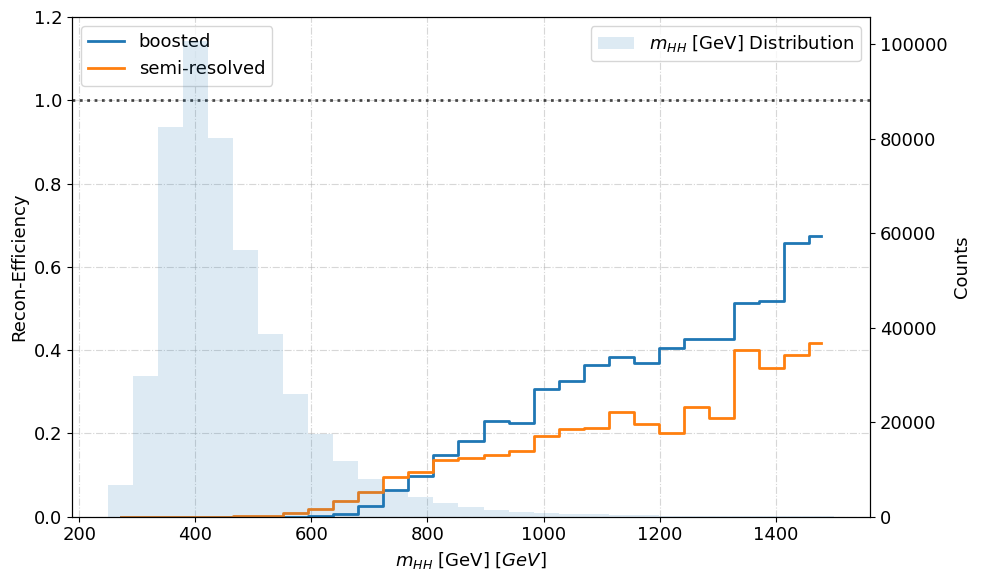

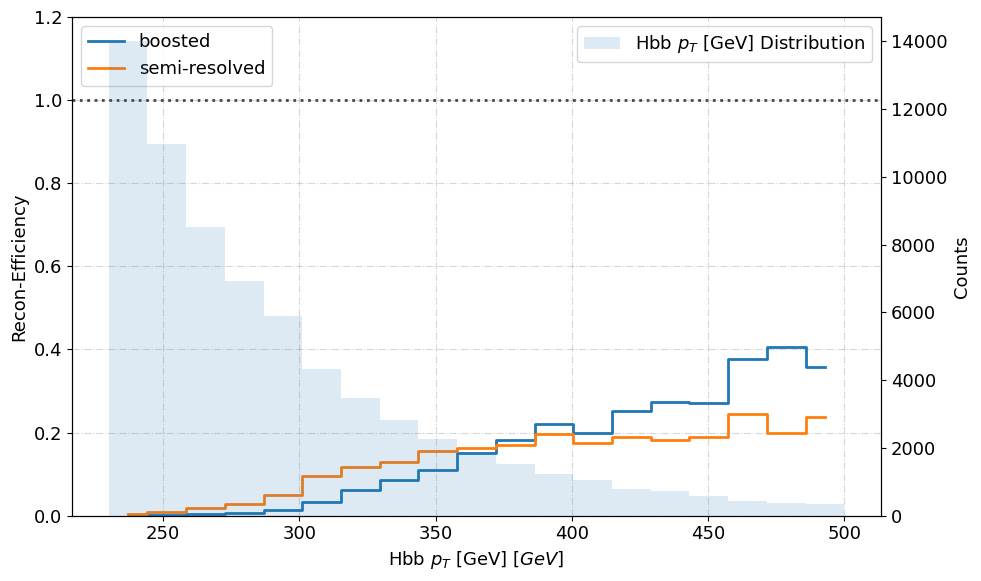

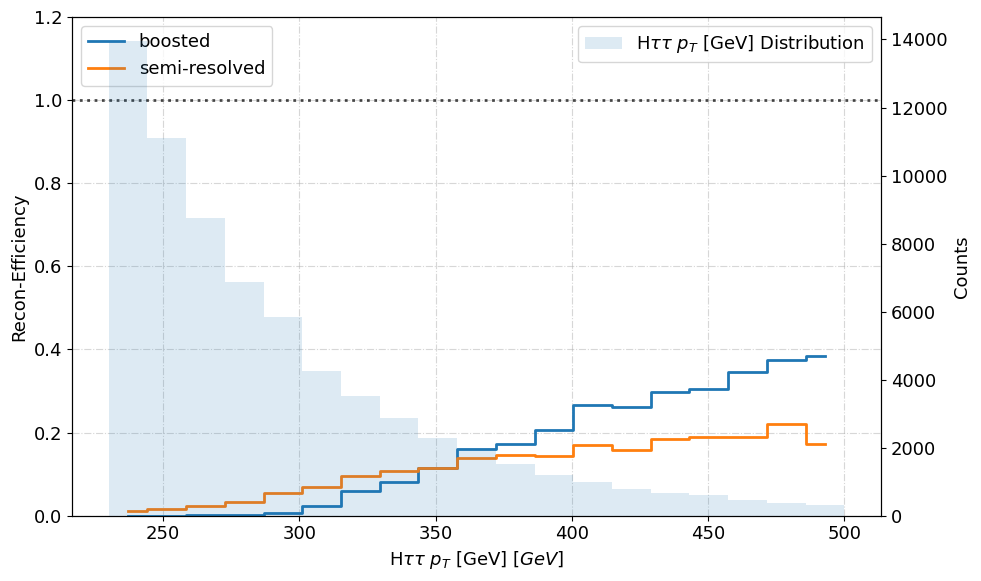

In [38]:
# (VOI) Variables Of Interest
weights = df["weight"][0]
higgs = utils.make_vector(df, name="GenHiggs")
mhh = (higgs[:, 0] + higgs[:, 1]).mass
hbbpt = higgs[df["GenHiggsChildren"] == 5].pt
httpt = higgs[df["GenHiggsChildren"] == 15].pt

plt.rcParams.update({'font.size':13})

plot_vars = [
    (mhh, "mhh", r"$m_{HH}$ [GeV]", np.linspace(250, 1500, 30)),
    (hbbpt, "hbbpt", r"Hbb $p_{T}$ [GeV]", np.linspace(230, 500, 20)),
    (httpt, "httpt", r"H$\tau\tau$ $p_{T}$ [GeV]", np.linspace(230, 500, 20)),
]

for kinvar, kinname, kinlabel, bins in plot_vars:
    eff_boost, tot, pas = efficiency_vs(kinvar, recon_truth_dict['boosted'], bins, weights)
    eff_semi , _,   _   = efficiency_vs(kinvar, recon_truth_dict['semi'], bins, weights)
    bc        = .5*(bins[1:]+bins[:-1])      

    # Add weights in the histograms
    fig,ax = plt.subplots(figsize=(10,6))
    ax.step(bc,eff_boost,where='mid',lw=2,
            label='boosted') 
    ax.step(bc,eff_semi   ,where='mid',lw=2,
            label='semi-resolved')
    ax.set(xlabel=kinlabel + r' [$GeV]$',ylabel='Recon-Efficiency',
           ylim=(0,1.2))

    ax.axhline(y=1, linestyle=':', color='black',
           alpha=0.7, linewidth=2)


    ax.grid(ls='-.',alpha=.5)

    ax2 = ax.twinx()
    ax2.bar(bc,tot,width=np.diff(bins),alpha=.15,
            label=kinlabel + ' Distribution')
    ax2.set_ylabel('Counts') # May be add weights in here

    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    


In [39]:
def delta_r_single(eta1: float, phi1: float,
                   eta2: float, phi2: float) -> float:
    dphi = (phi1 - phi2 + np.pi) % (2*np.pi) - np.pi
    return np.hypot(eta1 - eta2, dphi)

def match_event(jet_eta, jet_phi, jet_pt,
                obj_eta, obj_phi,
                dr_max: float, pt_min: float) -> np.ndarray:
    """
    Return Boolean matrix shape (njets, nobjects) saying whether
    jet j matches object k.  *Pure loops*.
    """
    nj, no = len(jet_eta), len(obj_eta)
    matched = np.zeros((nj, no), dtype=bool)
    for j in range(nj):
        if jet_pt[j] < pt_min:        # skip empty / low-pt slots
            continue
        for o in range(no):
            if delta_r_single(jet_eta[j], jet_phi[j],
                               obj_eta[o], obj_phi[o]) < dr_max:
                matched[j, o] = True
    return matched


In [40]:
N = len(df)
dr_ak8, dr_ak4 = 0.8, 0.4
pt8_min, pt4_min = 200., 20.

boosted_bb_pass      = np.zeros(N, dtype=bool)
boosted_tautau_pass  = np.zeros(N, dtype=bool)
is_2tautauak4        = np.zeros(N, dtype=bool)

for i in  tqdm(range(N)):
    # AK8 b-quark matching
    b_match_ak8 = match_event(ak8_eta[i], ak8_phi[i], ak8_pt[i],
                              b_eta[i], b_phi[i], dr_ak8, pt8_min)
    # both b’s in same AK8?
    both_b_in_same_ak8 = (b_match_ak8.sum(axis=1) == 2).any()
    boosted_bb_pass[i] = both_b_in_same_ak8

    # AK8 tau-pair matching
    tau_match_ak8 = match_event(ak8_eta[i], ak8_phi[i], ak8_pt[i],
                                tau_eta[i], tau_phi[i],
                                dr_ak8, pt8_min)
    both_tau_in_same_ak8 = (tau_match_ak8.sum(axis=1) == 2).any()
    boosted_tautau_pass[i] = both_tau_in_same_ak8

    # AK4 tau matching for semi-resolved
    tau_match_ak4 = match_event(ak4_eta[i], ak4_phi[i], ak4_pt[i],
                                tau_eta[i], tau_phi[i],
                                dr_ak4, pt4_min)
    # each tau matched to (a) some AK4 jet and (b) jets are different
    tau_hits = np.where(tau_match_ak4)[0]      # jet indices with τ
    is_2tautauak4[i] = (len(tau_hits) == 2 and
                        tau_hits[0] != tau_hits[1])

# -------------- boosted / semi categories at reco level -------------
boosted_pass = boosted_bb_pass & boosted_tautau_pass
semi_pass    = boosted_bb_pass & is_2tautauak4

recon_truth_dict = {
    'boosted': (boosted_pass, gen_boosted_pass),
    'semi'   : (semi_pass,    gen_semi_pass)
}


  1%|          | 9737/854042 [00:00<00:26, 32306.51it/s]

100%|██████████| 854042/854042 [00:26<00:00, 32004.36it/s]


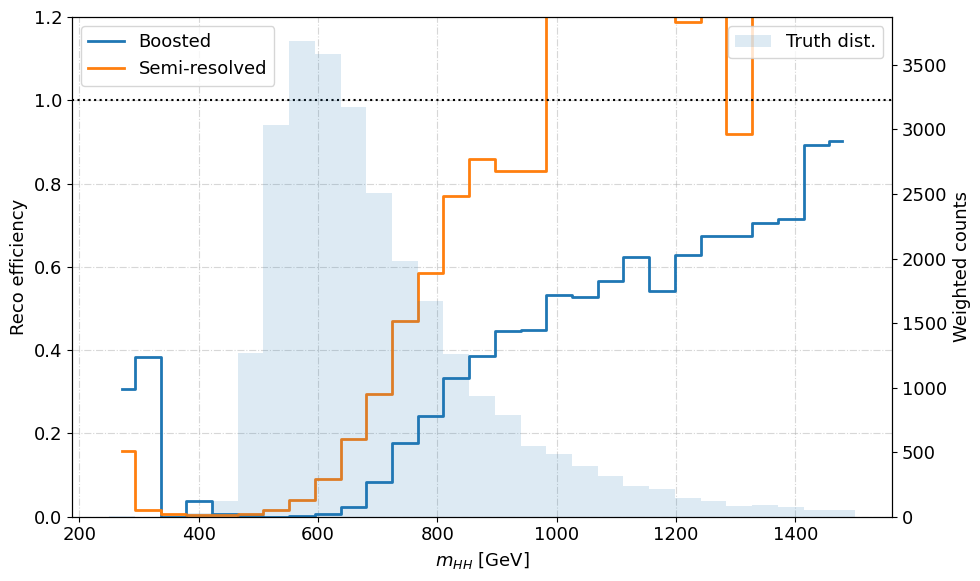

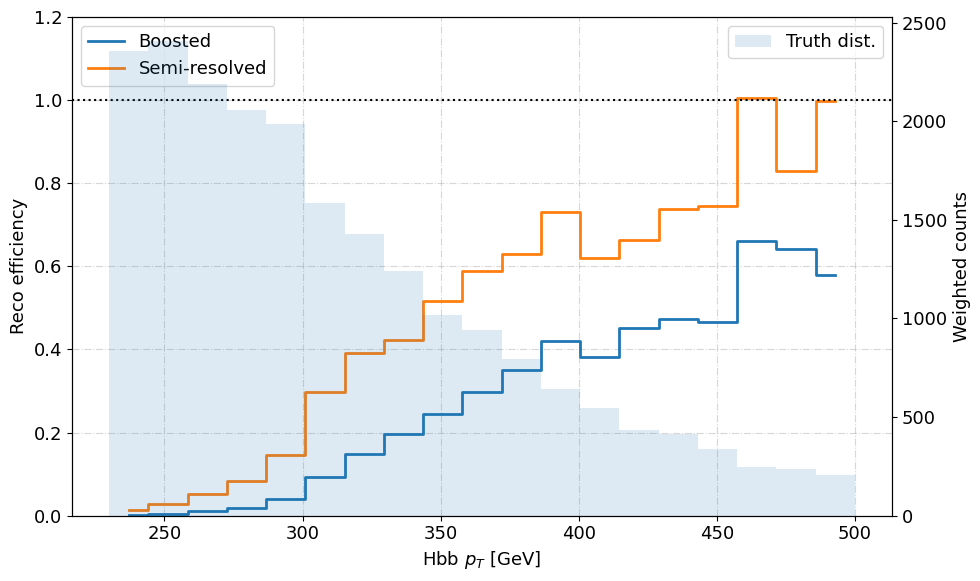

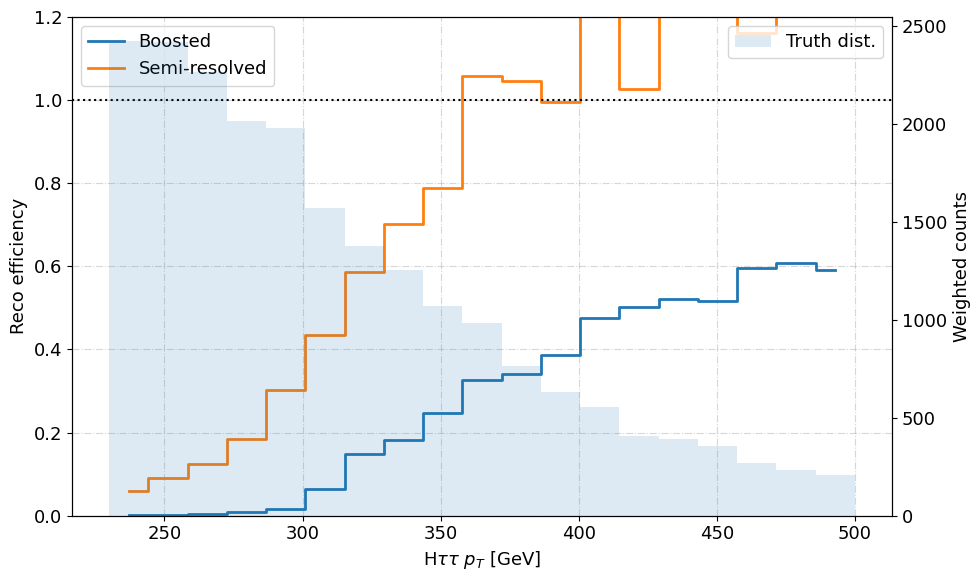

In [41]:

def efficiency_vs(var, masks, bins, wts):
    reco_mask, truth_mask = masks
    tot, _ = np.histogram(var[truth_mask], bins=bins, weights=wts[truth_mask])
    rec, _ = np.histogram(var[reco_mask],  bins=bins, weights=wts[reco_mask])
    with np.errstate(divide='ignore', invalid='ignore'):
        eff = rec / tot
    eff[tot == 0] = np.nan
    return eff, tot


for kin, name, label, bins in plot_vars:
    eff_b, tot_b = efficiency_vs(kin, recon_truth_dict['boosted'],
                                 bins, weights)
    eff_s, tot_s = efficiency_vs(kin, recon_truth_dict['semi'],
                                 bins, weights)
    bc = 0.5 * (bins[1:] + bins[:-1])

    fig, ax = plt.subplots(figsize=(10,6))
    ax.step(bc, eff_b, where='mid', lw=2, label='Boosted')
    ax.step(bc, eff_s, where='mid', lw=2, label='Semi-resolved')
    ax.set(xlabel=label, ylabel='Reco efficiency', ylim=(0,1.2))
    ax.axhline(1.0, ls=':', color='black', lw=1.5)
    ax.grid(ls='-.', alpha=0.5)

    ax2 = ax.twinx()
    ax2.bar(bc, tot_b, width=np.diff(bins), alpha=0.15,
            label='Truth dist.')
    ax2.set_ylabel('Weighted counts')

    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

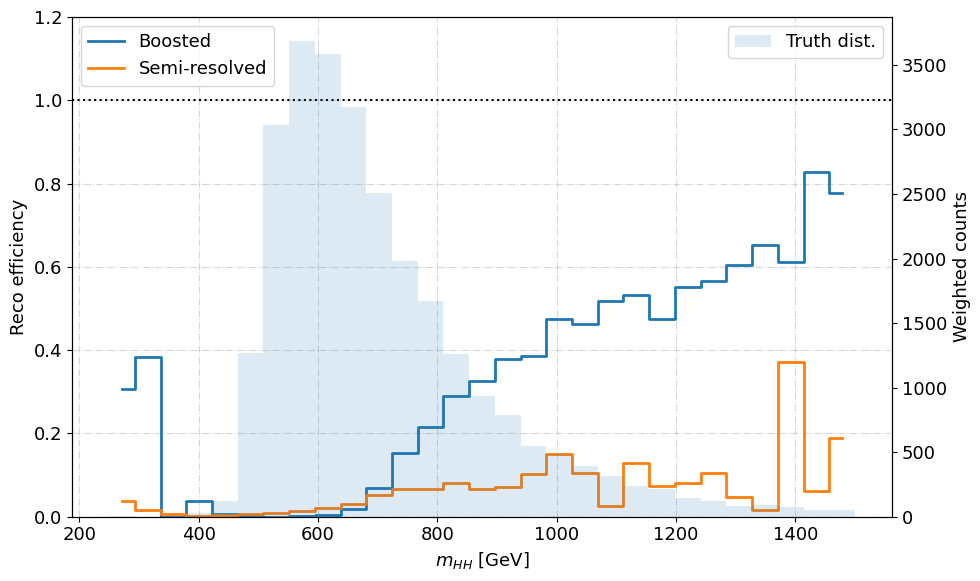

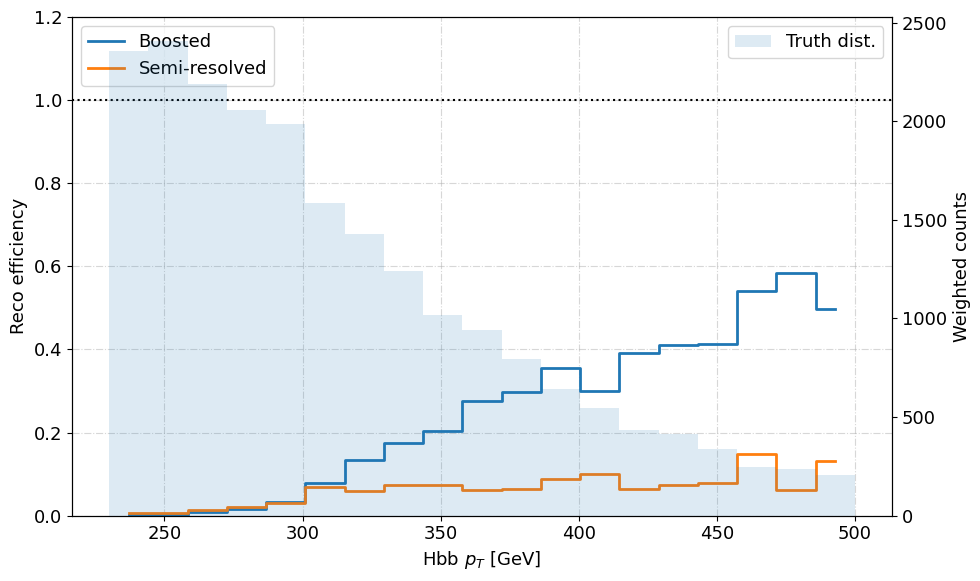

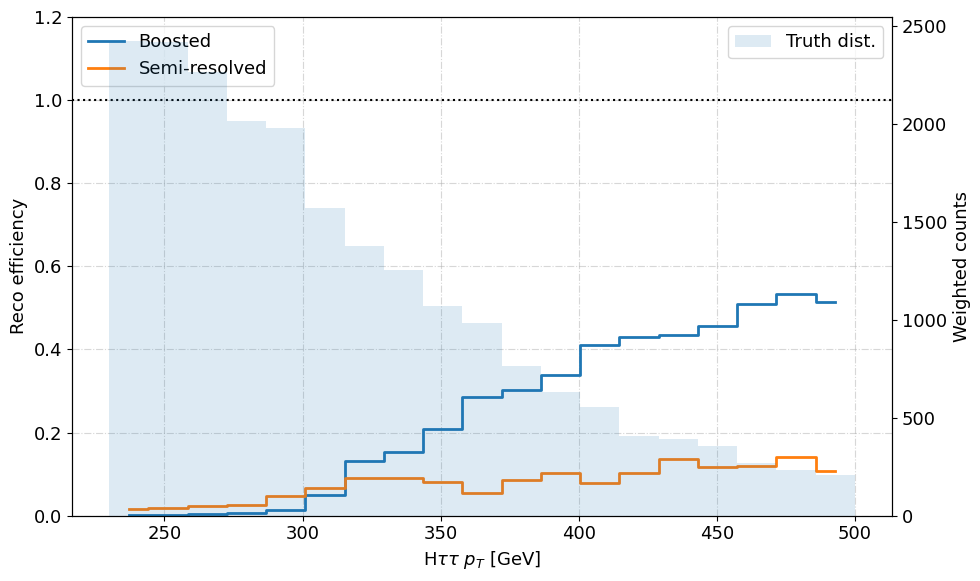

In [42]:

def efficiency_vs(var, masks, bins, wts):
    reco_mask, truth_mask = masks
    reco_mask = reco_mask & truth_mask
    tot, _ = np.histogram(var[truth_mask], bins=bins, weights=wts[truth_mask])
    rec, _ = np.histogram(var[reco_mask],  bins=bins, weights=wts[reco_mask])
    with np.errstate(divide='ignore', invalid='ignore'):
        eff = rec / tot
    eff[tot == 0] = np.nan
    return eff, tot


for kin, name, label, bins in plot_vars:
    eff_b, tot_b = efficiency_vs(kin, recon_truth_dict['boosted'],
                                 bins, weights)
    eff_s, tot_s = efficiency_vs(kin, recon_truth_dict['semi'],
                                 bins, weights)
    bc = 0.5 * (bins[1:] + bins[:-1])

    fig, ax = plt.subplots(figsize=(10,6))
    ax.step(bc, eff_b, where='mid', lw=2, label='Boosted')
    ax.step(bc, eff_s, where='mid', lw=2, label='Semi-resolved')
    ax.set(xlabel=label, ylabel='Reco efficiency', ylim=(0,1.2))
    ax.axhline(1.0, ls=':', color='black', lw=1.5)
    ax.grid(ls='-.', alpha=0.5)

    ax2 = ax.twinx()
    ax2.bar(bc, tot_b, width=np.diff(bins), alpha=0.15,
            label='Truth dist.')
    ax2.set_ylabel('Weighted counts')

    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

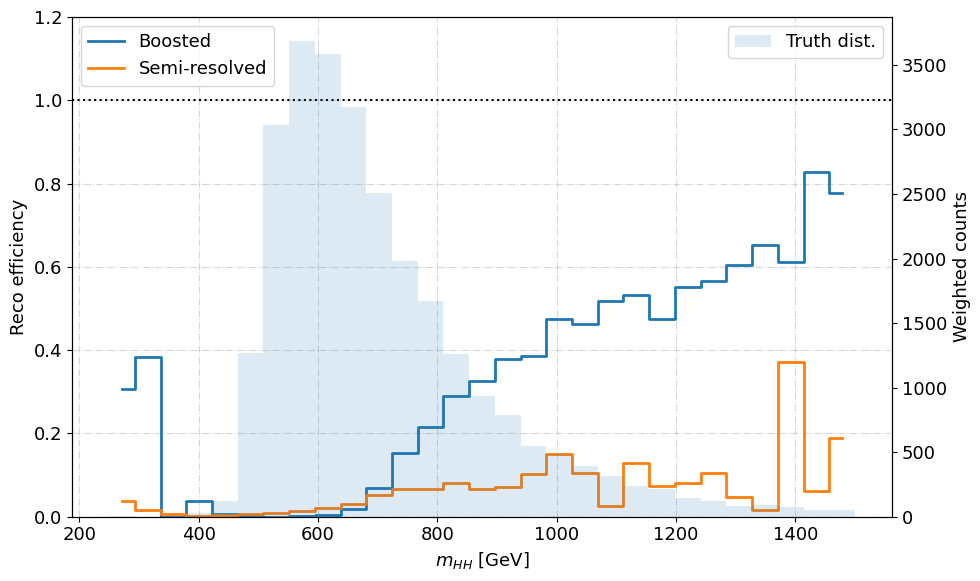

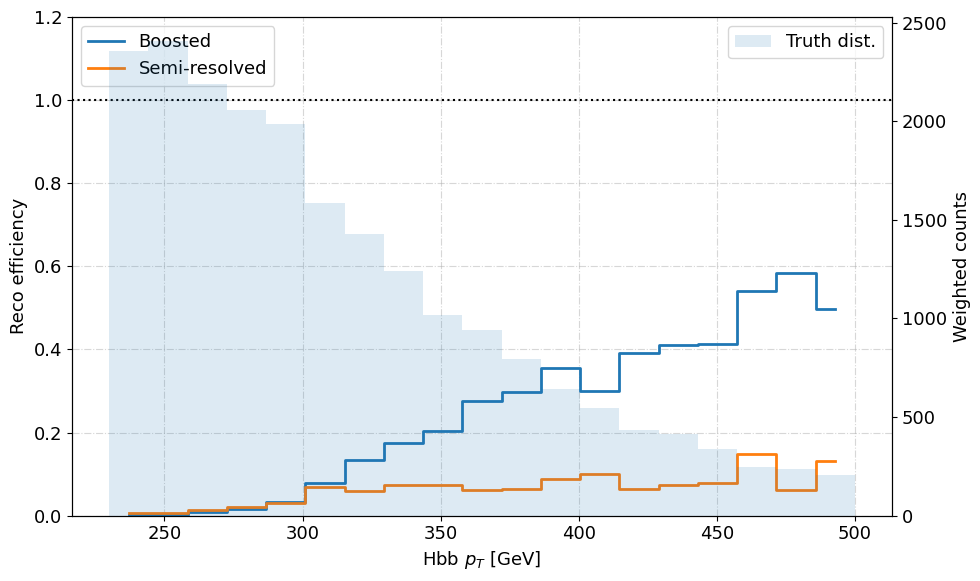

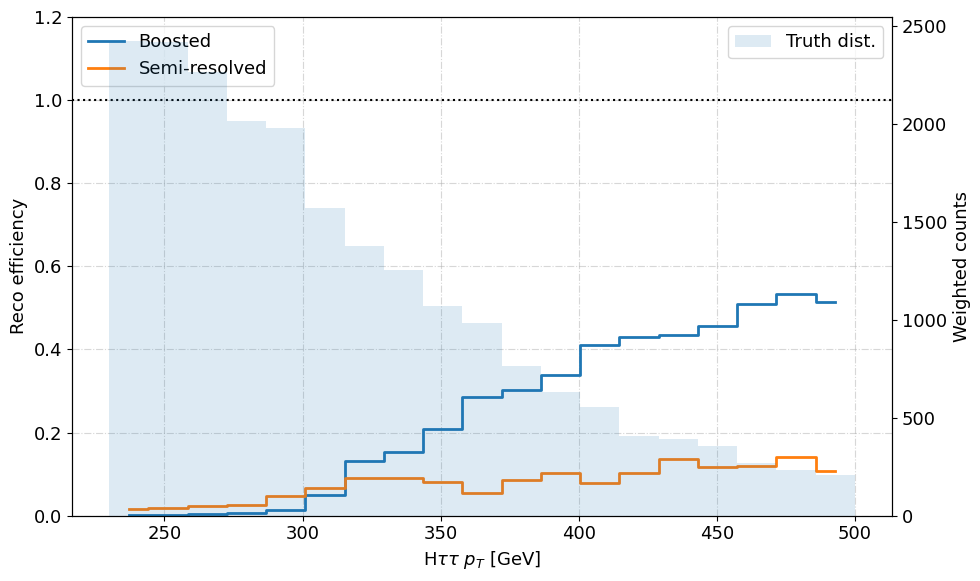

In [ ]:

def efficiency_vs(var, masks, bins, wts):
    reco_mask, truth_mask = masks
    reco_mask = reco_mask & truth_mask
    tot, _ = np.histogram(var, bins=bins, weights=wts)
    rec, _ = np.histogram(var[reco_mask],  bins=bins, weights=wts[reco_mask])
    with np.errstate(divide='ignore', invalid='ignore'):
        eff = rec / tot
    eff[tot == 0] = np.nan
    return eff, tot


for kin, name, label, bins in plot_vars:
    eff_b, tot_b = efficiency_vs(kin, recon_truth_dict['boosted'],
                                 bins, weights)
    eff_s, tot_s = efficiency_vs(kin, recon_truth_dict['semi'],
                                 bins, weights)
    bc = 0.5 * (bins[1:] + bins[:-1])

    fig, ax = plt.subplots(figsize=(10,6))
    ax.step(bc, eff_b, where='mid', lw=2, label='Boosted')
    ax.step(bc, eff_s, where='mid', lw=2, label='Semi-resolved')
    ax.set(xlabel=label, ylabel='Reco efficiency', ylim=(0,1.2))
    ax.axhline(1.0, ls=':', color='black', lw=1.5)
    ax.grid(ls='-.', alpha=0.5)

    ax2 = ax.twinx()
    ax2.bar(bc, tot_b, width=np.diff(bins), alpha=0.15,
            label='Truth dist.')
    ax2.set_ylabel('Weighted counts')

    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()